# <생존 분석>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## <카플란 마이어>

In [2]:
url = "https://github.com/ADPclass/ADP_book_ver01/blob/main/data/28_problem4.csv?raw=true"

df = pd.read_csv(url)
df

,time(month),survival,company
0,39,Y,B
1,29,Y,B
2,15,N,B
3,43,N,A
4,8,Y,A
...,...,...,...
1995,34,N,B
1996,36,Y,B
1997,6,N,B
1998,39,Y,A


In [3]:
### 전처리
df["survival"].value_counts()

N    1018
Y     982
Name: survival, dtype: int64

In [4]:
print("""
사망이면 1 생존이면 0으로 라벨링 진행
""")


사망이면 1 생존이면 0으로 라벨링 진행



In [5]:
def sep_survival(x):
    if x == "N":
        return 1
    else:
        return 0

df["survival"] = df["survival"].apply(sep_survival)
df

,time(month),survival,company
0,39,0,B
1,29,0,B
2,15,1,B
3,43,1,A
4,8,0,A
...,...,...,...
1995,34,1,B
1996,36,0,B
1997,6,1,B
1998,39,0,A


In [6]:
### 그룹 나누기

cond = (df["company"] == "A")
cond1 = (df["company"] == "B")

dfA = df.loc[cond, :].copy()
dfB = df.loc[cond1, :].copy()

In [7]:
### 카플란 마이어 생존분석 (회사A)
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
        durations=dfA["time(month)"],
        event_observed=dfA["survival"]
        )

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1034 total observations, 507 right-censored observations>

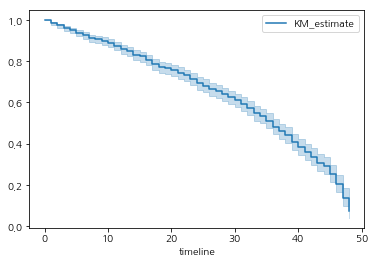

In [8]:
### 생존곡선 시각화 (회사 A)
kmf.plot_survival_function()

In [9]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
1.0,0.985493
2.0,0.974792
3.0,0.960097
4.0,0.951188
5.0,0.939224
6.0,0.928127
7.0,0.914838
8.0,0.908657


In [10]:
### 카플란 마이어 생존분석 (회사B)
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
        durations=dfB["time(month)"],
        event_observed=dfB["survival"]
        )

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 966 total observations, 475 right-censored observations>

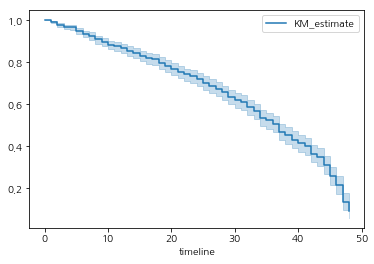

In [11]:
### 생존곡선 시각화 (회사 B)
kmf.plot_survival_function()

In [12]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
1.0,0.992754
2.0,0.979126
3.0,0.969568
4.0,0.966347
5.0,0.951025
6.0,0.935615
7.0,0.926757
8.0,0.908914


In [13]:
### log-rank 검정
from lifelines.statistics import logrank_test

# H0 : 두 회사의 생존곡선이 같다.
# H1 : 두 회사의 생존곡선이 다르다.


result = logrank_test(
                      durations_A=dfA["time(month)"],
                      durations_B=dfB["time(month)"],
                      event_observed_A=dfA["survival"],
                      event_observed_B=dfB["survival"]       
                      )
print(result)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.76 0.38      1.38


In [14]:
s = result.test_statistic
p = result.p_value

print(f"검정통계량 : {s}")
print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 두 회사의 생존 곡선은 같다.")

검정통계량 : 0.7610789408101652
검정통계량의 p-value : 0.38299108168197027
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 두 회사의 생존 곡선은 같다.


## <콕스비례 위험>

관측기간: time_days (일)

사건여부: event (1=해지, 0=사용 중)

공변량(설명변수): 
- plan(Free/Standard/Premium) 
- age
- sessions_per_week 
- region(Seoul/Busan/Daegu/Gwangju)
- device(Android/iOS/Desktop)
- promo_used(0/1)
- family_plan(0/1)

In [15]:
## 원본 데이터
file_path = "./data/cox_data.csv"
df = pd.read_csv(file_path)
df

,time_days,event,plan,age,sessions_per_week,region,device,promo_used,family_plan
0,14.9,1,Standard,58,3.42,Seoul,iOS,1,0
1,42.1,0,Standard,52,4.15,Seoul,Android,1,1
2,335.8,1,Premium,66,4.68,Busan,iOS,1,0
3,50.9,0,Standard,67,5.71,Seoul,Android,1,0
4,8.0,1,Free,54,6.66,Seoul,Android,0,0
...,...,...,...,...,...,...,...,...,...
1495,80.3,1,Standard,50,2.92,Gwangju,iOS,0,0
1496,134.7,0,Premium,35,3.10,Seoul,Android,1,1
1497,99.3,1,Standard,38,4.17,Seoul,iOS,1,0
1498,48.8,1,Free,30,2.38,Seoul,iOS,1,0


In [16]:
### 원본 데이터
df

,time_days,event,plan,age,sessions_per_week,region,device,promo_used,family_plan
0,14.9,1,Standard,58,3.42,Seoul,iOS,1,0
1,42.1,0,Standard,52,4.15,Seoul,Android,1,1
2,335.8,1,Premium,66,4.68,Busan,iOS,1,0
3,50.9,0,Standard,67,5.71,Seoul,Android,1,0
4,8.0,1,Free,54,6.66,Seoul,Android,0,0
...,...,...,...,...,...,...,...,...,...
1495,80.3,1,Standard,50,2.92,Gwangju,iOS,0,0
1496,134.7,0,Premium,35,3.10,Seoul,Android,1,1
1497,99.3,1,Standard,38,4.17,Seoul,iOS,1,0
1498,48.8,1,Free,30,2.38,Seoul,iOS,1,0


In [17]:
print("""
plan, region, device 컬럼 라벨 인코딩 진행
""")


plan, region, device 컬럼 라벨 인코딩 진행



In [18]:
## 원-핫 인코딩

df = pd.get_dummies(df,
                    columns=["plan", "region", "device"],
                    drop_first=True,
                    dtype="int")
df

,time_days,event,age,sessions_per_week,promo_used,family_plan,plan_Premium,plan_Standard,region_Daegu,region_Gwangju,region_Seoul,device_Desktop,device_iOS
0,14.9,1,58,3.42,1,0,0,1,0,0,1,0,1
1,42.1,0,52,4.15,1,1,0,1,0,0,1,0,0
2,335.8,1,66,4.68,1,0,1,0,0,0,0,0,1
3,50.9,0,67,5.71,1,0,0,1,0,0,1,0,0
4,8.0,1,54,6.66,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,80.3,1,50,2.92,0,0,0,1,0,1,0,0,1
1496,134.7,0,35,3.10,1,1,1,0,0,0,1,0,0
1497,99.3,1,38,4.17,1,0,0,1,0,0,1,0,1
1498,48.8,1,30,2.38,1,0,0,0,0,0,1,0,1


In [19]:
## 콕스 회귀분석
from lifelines import CoxPHFitter

cpf = CoxPHFitter()

cpf.fit(df,                            ### 원본 데이터
        duration_col="time_days",      ## 종속변수1 (시간)
        event_col="event"              ## 종속변수2 (사건 여/부)
        )

result = cpf.summary
result

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
age,-0.005898,0.994120,0.002204,-0.010218,-0.001577,0.989834,0.998424,0.0,-2.675373,7.464611e-03,7.065717
sessions_per_week,0.000634,1.000634,0.017189,-0.033055,0.034323,0.967485,1.034919,0.0,0.036874,9.705857e-01,0.043073
promo_used,0.083523,1.087111,0.066942,-0.047680,0.214727,0.953438,1.239524,0.0,1.247699,2.121413e-01,2.236903
family_plan,-0.128843,0.879112,0.066816,-0.259800,0.002115,0.771206,1.002117,0.0,-1.928308,5.381678e-02,4.215800
plan_Premium,-0.621963,0.536889,0.096027,-0.810173,-0.433753,0.444781,0.648072,0.0,-6.476948,9.359643e-11,33.314756
plan_Standard,-0.264178,0.767837,0.073934,-0.409085,-0.119271,0.664258,0.887567,0.0,-3.573183,3.526684e-04,11.469400
region_Daegu,-0.250772,0.778200,0.121099,-0.488121,-0.013422,0.613779,0.986667,0.0,-2.070802,3.837731e-02,4.703603
region_Gwangju,0.077175,1.080231,0.135589,-0.188574,0.342924,0.828140,1.409061,0.0,0.569186,5.692302e-01,0.812916
region_Seoul,-0.076770,0.926103,0.088314,-0.249863,0.096323,0.778907,1.101115,0.0,-0.869281,3.846936e-01,1.378218


In [20]:
### 비례위험 가정 검정

cpf.check_assumptions(df,               ## 원본 데이터
                      show_plots=True   # 시각적 진단 그래프까지 보고싶을 때
                      )

Proportional hazard assumption looks okay.


[]

In [21]:
print("비례위험 가정 충족되어 콕스 회귀 분석결과가 신뢰가능해졌다.")

비례위험 가정 충족되어 콕스 회귀 분석결과가 신뢰가능해졌다.


In [22]:
### 회귀계수 통계적 유의성 검정

result["p"] < 0.05

covariate
age                   True
sessions_per_week    False
promo_used           False
family_plan          False
plan_Premium          True
plan_Standard         True
region_Daegu          True
region_Gwangju       False
region_Seoul         False
device_Desktop       False
device_iOS           False
Name: p, dtype: bool

In [25]:
cpf.AIC_partial_

11448.133488452391

In [26]:
### 위험비(HR)
result["exp(coef)"]

covariate
age                  0.994120
sessions_per_week    1.000634
promo_used           1.087111
family_plan          0.879112
plan_Premium         0.536889
plan_Standard        0.767837
region_Daegu         0.778200
region_Gwangju       1.080231
region_Seoul         0.926103
device_Desktop       1.070384
device_iOS           0.971569
Name: exp(coef), dtype: float64

In [68]:
### 위험비(HR) 해석
(result["exp(coef)"]-1)*100

covariate
age                  -0.588044
sessions_per_week     0.063401
promo_used            8.711062
family_plan         -12.088761
plan_Premium        -46.311060
plan_Standard       -23.216316
region_Daegu        -22.179994
region_Gwangju        8.023114
region_Seoul         -7.389723
device_Desktop        7.038390
device_iOS           -2.843119
Name: exp(coef), dtype: float64

In [69]:
## 우도비 검정

result = cpf.log_likelihood_ratio_test()

print(result)           ### print 안하면 오류난다.

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 11
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          62.81 <0.005     28.43


In [70]:
# H0 : 모든 회귀계수는 0이다.(=모델이 통계적으로 유의하지 않다.)
# H1 : 적어도 하나의 회귀계수는 0이 아니다.(=모델이 통계적으로 유의하다.)

s = result.test_statistic
p = result.p_value

print(f"우도비 검정통계량 : {s}")
print(f"우도비 검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

우도비 검정통계량 : 62.81287035510286
우도비 검정통계량의 p-value : 2.7718001386091195e-09
귀무가설 기각


In [71]:
### 생존 확률 예측

# 예측값
pred = pd.DataFrame([[25, 10.5, 1, 1, 1, 0, 1, 0, 0, 0, 1]],
                    columns=["age", "sessions_per_week", "promo_used",
                             "family_plan", "plan_Premium", "plan_Standard",
                             "region_Daegu", "region_Gwangju", "region_Seoul",
                             "device_Desktop", "device_iOS"])

survival_func = cpf.predict_survival_function(pred)
survival_func

,0
0.0,1.000000
0.1,0.999609
0.2,0.999218
0.3,0.998826
0.4,0.998434
...,...
668.2,0.074549
678.2,0.074549
700.1,0.052528
728.1,0.052528


In [72]:
### 기대 생존시간

# 예측값
pred = pd.DataFrame([[25, 10.5, 1, 1, 1, 0, 1, 0, 0, 0, 1]],
                    columns=["age", "sessions_per_week", "promo_used",
                             "family_plan", "plan_Premium", "plan_Standard",
                             "region_Daegu", "region_Gwangju", "region_Seoul",
                             "device_Desktop", "device_iOS"])

result = cpf.predict_expectation(pred)
print(f"기대 생존시간 : {result[0]}일")

기대 생존시간 : 248.5349714796801일
